# Krishna River — LightGBM Model

**Input:** `krishna_features.csv` (from `04_krishna_feature_engineering.ipynb`)

**Goal:** beat Model 1 (Random Forest) using LightGBM's sequential, error-correcting tree structure — expected to help most with the extreme flood-peak predictions Random Forest tends to average away.

**Benchmarks to beat, from `05_krishna_split_and_baseline_model.ipynb`:**

| | Val MAE | Val NSE | Test MAE | Test NSE |
|---|---|---|---|---|
| Persistence baseline | 55.13 | 0.738 | 54.27 | 0.624 |
| Random Forest (log-transformed) | 53.86 | 0.755 | 53.24 | 0.704 |

Same rules as before: validation set for comparing configurations, test set touched exactly once at the end.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df_features = pd.read_csv("../data/processed/krishna_features.csv", parse_dates=["date"])
df_features = df_features.dropna(subset=[c for c in df_features.columns if "lag" in c or "sum" in c])
print(f"Rows: {len(df_features)}")

Rows: 306588


In [2]:
train = df_features[df_features["date"] <= "2020-12-31"]
val   = df_features[(df_features["date"] >= "2021-01-01") & (df_features["date"] <= "2022-12-31")]
test  = df_features[df_features["date"] >= "2023-01-01"]

feature_cols = [c for c in df_features.columns if "lag" in c or "sum" in c] + ["is_monsoon", "month"]
target_col = "streamflow"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

# Same log-transform as the Random Forest model — LightGBM benefits from it
# for the same reason: without it, huge-magnitude rivers dominate the loss
# at the expense of getting small rivers right.
y_train_log = np.log1p(y_train)

def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 224884, Val: 34557, Test: 47147


## 1. LightGBM — same features as the winning Random Forest config

Starting from the exact feature set that won in notebook 05 (lags, rainfall sums, month, is_monsoon — no station identity, no raw ENSO/temperature yet), so any difference in the result is attributable to the model itself, not a changed feature set.

In [3]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, np.log1p(y_val))],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

val_pred_lgb = np.expm1(lgb_model.predict(X_val))
mae_lgb = mean_absolute_error(y_val, val_pred_lgb)
nse_lgb = nse(y_val, val_pred_lgb)

print(f"LightGBM        — MAE: {mae_lgb:.2f}, NSE: {nse_lgb:.3f}")
print(f"Random Forest    — MAE: 53.86, NSE: 0.755")
print(f"Persistence      — MAE: 55.13, NSE: 0.738")
print(f"\nBest iteration (early stopping): {lgb_model.best_iteration_}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1800
[LightGBM] [Info] Number of data points in the train set: 224884, number of used features: 9
[LightGBM] [Info] Start training from score 1.991081


c:\Users\yadny\OneDrive\Desktop\Yadnyesh\ResumeProjects\river_streamflow_forecast\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM        — MAE: 54.78, NSE: 0.765
Random Forest    — MAE: 53.86, NSE: 0.755
Persistence      — MAE: 55.13, NSE: 0.738

Best iteration (early stopping): 123


**Note on `early_stopping`:** unlike Random Forest, boosting can overfit if you just let it run for the full `n_estimators`. Early stopping watches validation MAE during training and halts once it stops improving — this is standard practice for boosted trees and something Random Forest doesn't need, since each of its trees is independent rather than sequentially correcting the last one.

## 2. Feature importance — sanity check against the Random Forest result

In [4]:
importances = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

streamflow_lag_1    1040
rainfall_sum_3d      706
streamflow_lag_7     548
streamflow_lag_3     375
streamflow_lag_2     373
rainfall_sum_14d     247
rainfall_sum_7d      194
month                176
is_monsoon            31
dtype: int32


Expect a similar shape to Random Forest's importances (`streamflow_lag_1` dominant, rainfall sums secondary) — if the ranking looks wildly different, that's worth investigating before trusting the result, since it would suggest the two models are learning genuinely different things rather than one just refining the other.

## 3. Does adding ENSO/temperature help LightGBM?

Same test as Section 7 of notebook 05, repeated here for LightGBM specifically — a feature that doesn't help one model type can still help another, since boosting and Random Forest weight features differently.

In [5]:
feature_cols_enso = feature_cols + ["oni_3month_avg", "tmax"]
X_train_enso = train[feature_cols_enso]
X_val_enso = val[feature_cols_enso]

lgb_enso = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=31,
    random_state=42, n_jobs=-1,
)
lgb_enso.fit(
    X_train_enso, y_train_log,
    eval_set=[(X_val_enso, np.log1p(y_val))],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

val_pred_enso = np.expm1(lgb_enso.predict(X_val_enso))
print(f"With oni_3month_avg + tmax — MAE: {mean_absolute_error(y_val, val_pred_enso):.2f}, NSE: {nse(y_val, val_pred_enso):.3f}")
print(f"Without (Section 1)       — MAE: {mae_lgb:.2f}, NSE: {nse_lgb:.3f}")
print()
print(pd.Series(lgb_enso.feature_importances_, index=feature_cols_enso).sort_values(ascending=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2310
[LightGBM] [Info] Number of data points in the train set: 224884, number of used features: 11
[LightGBM] [Info] Start training from score 1.991081


c:\Users\yadny\OneDrive\Desktop\Yadnyesh\ResumeProjects\river_streamflow_forecast\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


With oni_3month_avg + tmax — MAE: 53.81, NSE: 0.773
Without (Section 1)       — MAE: 54.78, NSE: 0.765

streamflow_lag_1    1186
rainfall_sum_3d      742
streamflow_lag_7     664
streamflow_lag_2     484
streamflow_lag_3     468
tmax                 424
rainfall_sum_14d     355
oni_3month_avg       334
rainfall_sum_7d      283
month                186
is_monsoon            34
dtype: int32


**Fill in after running:** keep whichever configuration (with or without ENSO/temperature) performs better on validation — carry that choice into Section 4 below.

## 4. Final model — one-time test evaluation

Uses whichever configuration won in Sections 1–3. **Update the `final_features` variable below to match your decision before running.**

In [6]:
# Set this to `feature_cols` or `feature_cols_enso` based on which won on validation above
final_features = feature_cols

X_train_final = train[final_features]
X_test_final = test[final_features]

final_lgb = lgb.LGBMRegressor(
    n_estimators=lgb_model.best_iteration_,
    learning_rate=0.05, max_depth=8, num_leaves=31,
    random_state=42, n_jobs=-1,
)
final_lgb.fit(X_train_final, y_train_log)

test_pred_lgb = np.expm1(final_lgb.predict(X_test_final))
test_mae_lgb = mean_absolute_error(y_test, test_pred_lgb)
test_rmse_lgb = mean_squared_error(y_test, test_pred_lgb) ** 0.5
test_nse_lgb = nse(y_test, test_pred_lgb)

print("FINAL TEST RESULTS — LightGBM")
print(f"MAE:  {test_mae_lgb:.2f}")
print(f"RMSE: {test_rmse_lgb:.2f}")
print(f"NSE:  {test_nse_lgb:.3f}")

print("\nFor comparison (from notebook 05):")
print("Random Forest — Test MAE: 53.24, Test RMSE: 401.75, Test NSE: 0.704")
print("Persistence   — Test MAE: 54.27, Test NSE: 0.624")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1800
[LightGBM] [Info] Number of data points in the train set: 224884, number of used features: 9
[LightGBM] [Info] Start training from score 1.991081
FINAL TEST RESULTS — LightGBM
MAE:  55.31
RMSE: 411.55
NSE:  0.690

For comparison (from notebook 05):
Random Forest — Test MAE: 53.24, Test RMSE: 401.75, Test NSE: 0.704
Persistence   — Test MAE: 54.27, Test NSE: 0.624


## 5. Diagnostic: flood-peak tracking

Same station and same test window as notebook 05's diagnostic plot, so the two models' handling of the Wadenepally flood period can be compared directly, side by side.

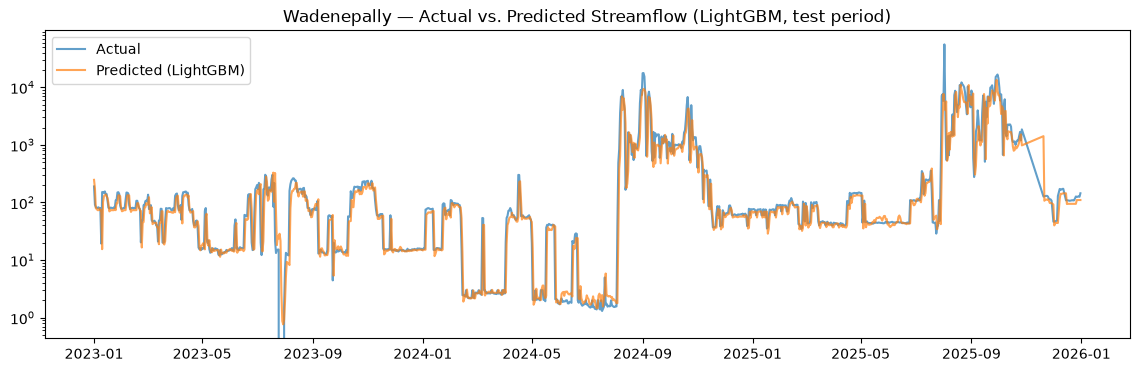

In [7]:
sub_station = "Wadenepally"
mask = test["station_name"] == sub_station
plot_dates = test.loc[mask, "date"]
plot_actual = y_test[mask]
plot_pred_lgb = test_pred_lgb[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_dates, plot_actual, label="Actual", alpha=0.7)
ax.plot(plot_dates, plot_pred_lgb, label="Predicted (LightGBM)", alpha=0.7)
ax.set_yscale("log")
ax.set_title(f"{sub_station} — Actual vs. Predicted Streamflow (LightGBM, test period)")
ax.legend()
plt.show()

## 6. Summary & Decision

**Fill in after running the notebook:**
- Did LightGBM beat Random Forest on test MAE/NSE?
- Did it visibly track the Wadenepally flood peak better or worse than Random Forest (Section 5 vs. notebook 05 Section 9)?
- Did ENSO/temperature end up helping LightGBM even if it didn't help Random Forest, or vice versa?

**Decision point:** if LightGBM wins clearly, it becomes the new baseline to beat. If it's a similar wash to the station-identity result in notebook 05 (small/no real improvement), that's useful information too — it suggests tree-based models are converging on roughly the same ceiling with these features, and the next real gain is more likely to come from either better features (e.g. rate-of-change lags, upstream-station data) or a genuinely different model family (LSTM/TCN) rather than swapping between tree ensembles.

**Next steps:**
- If LightGBM wins: make it the model used for the Kaveri basin pipeline once that's picked back up
- If flood-peak tracking is still weak on both tree models: this is the strongest signal to move to an LSTM/TCN next, since that's specifically the failure mode sequence models are suited to address
- Either way: repeat the full pipeline (cleaning → coverage → features → baseline → ENSO analysis → best model) on Kaveri, deferred earlier in this project